library

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

DATASET

In [2]:
N = 600
img_size = 16

X = np.random.rand(N, img_size, img_size)

y = ((np.sum(X[:,4:12,4:12],axis=(1,2))) > 32).astype(int).reshape(-1,1)

idx = np.random.permutation(N)

train_end = int(0.7*N)
val_end = int(0.85*N)

train_idx = idx[:train_end]
val_idx = idx[train_end:val_end]
test_idx = idx[val_end:]

X_train,y_train = X[train_idx],y[train_idx]
X_val,y_val = X[val_idx],y[val_idx]
X_test,y_test = X[test_idx],y[test_idx]

ACTIVATIONS

In [3]:
def relu(z):
    return np.maximum(0,z)

def sigmoid(z):
    z = np.clip(z,-500,500)
    return 1/(1+np.exp(-z))

LOSS

In [4]:
def BCE(y,yhat):

    eps=1e-8
    yhat=np.clip(yhat,eps,1-eps)

    return -np.mean(y*np.log(yhat)+(1-y)*np.log(1-yhat))

CONVOLUTION

In [5]:
def conv2d(image,kernel):

    k = kernel.shape[0]
    h,w = image.shape

    out_size = h-k+1

    output=np.zeros((out_size,out_size))

    for i in range(out_size):
        for j in range(out_size):

            region=image[i:i+k,j:j+k]
            output[i,j]=np.sum(region*kernel)

    return output


MAXPOOL

In [6]:
def maxpool(feature,size=2):

    h,w = feature.shape
    out = np.zeros((h//size,w//size))

    for i in range(0,h,size):
        for j in range(0,w,size):

            region = feature[i:i+size,j:j+size]
            out[i//size,j//size]=np.max(region)

    return out


FORWARD PASS

In [7]:
def forward(img,kernel,dense_w,dense_b):

    conv = conv2d(img,kernel)
    act = relu(conv)
    pool = maxpool(act)

    flat = pool.flatten().reshape(1,-1)

    z = flat @ dense_w + dense_b
    yhat = sigmoid(z)

    cache=(img,conv,act,pool,flat)

    return yhat,cache

OPTIMIZERS

In [8]:
def update_sgd(w,dw,lr):
    return w - lr*dw

def update_momentum(w,dw,v,lr,beta=0.9):

    v = beta*v + (1-beta)*dw
    w = w - lr*v

    return w,v

def update_adam(w,dw,m,v,t,
                lr=0.001,
                beta1=0.9,
                beta2=0.999,
                eps=1e-8):

    m = beta1*m + (1-beta1)*dw
    v = beta2*v + (1-beta2)*(dw**2)

    m_hat = m/(1-beta1**t)
    v_hat = v/(1-beta2**t)

    w = w - lr*m_hat/(np.sqrt(v_hat)+eps)

    return w,m,v


TRAIN FUNCTION

In [9]:
def train_optimizer(optimizer):

    kernel = np.random.randn(3,3)*0.01
    dense_w = np.random.randn(49,1)*0.01
    dense_b = 0

    lr=0.01
    epochs=30

    v=np.zeros_like(dense_w)
    m=np.zeros_like(dense_w)
    v_adam=np.zeros_like(dense_w)

    train_losses=[]

    for epoch in range(epochs):

        losses=[]

        for i in range(len(X_train)):

            img=X_train[i]
            target=y_train[i]

            yhat,cache = forward(img,kernel,dense_w,dense_b)

            loss=BCE(target,yhat)
            losses.append(loss)

            img,conv,act,pool,flat = cache

            dZ = yhat-target
            dW = flat.T @ dZ

            if optimizer=="sgd":

                dense_w = update_sgd(dense_w,dW,lr)

            elif optimizer=="momentum":

                dense_w,v = update_momentum(dense_w,dW,v,lr)

            elif optimizer=="adam":

                dense_w,m,v_adam = update_adam(
                    dense_w,dW,m,v_adam,epoch+1
                )

        train_losses.append(np.mean(losses))

        if epoch%5==0:
            print(optimizer,"Epoch",epoch,"Loss",np.mean(losses))

    return dense_w,kernel,train_losses


RUN EXPERIMENTS

In [10]:
sgd_w,kernel_sgd,sgd_loss = train_optimizer("sgd")
mom_w,kernel_mom,mom_loss = train_optimizer("momentum")
adam_w,kernel_adam,adam_loss = train_optimizer("adam")

sgd Epoch 0 Loss 0.6930826704294505
sgd Epoch 5 Loss 0.6929261318716211
sgd Epoch 10 Loss 0.6927755526754295
sgd Epoch 15 Loss 0.6926306974557691
sgd Epoch 20 Loss 0.6924913400984517
sgd Epoch 25 Loss 0.6923572633990199
momentum Epoch 0 Loss 0.692944487589893
momentum Epoch 5 Loss 0.692025729980716
momentum Epoch 10 Loss 0.6913045907349067
momentum Epoch 15 Loss 0.690738160034756
momentum Epoch 20 Loss 0.6902923951167234
momentum Epoch 25 Loss 0.6899407484605241
adam Epoch 0 Loss 0.6929880671771674
adam Epoch 5 Loss 0.692198040130492
adam Epoch 10 Loss 0.6918515798906882
adam Epoch 15 Loss 0.6915549182400416
adam Epoch 20 Loss 0.691279719457764
adam Epoch 25 Loss 0.6910192968158767


PLOT COMPARISON

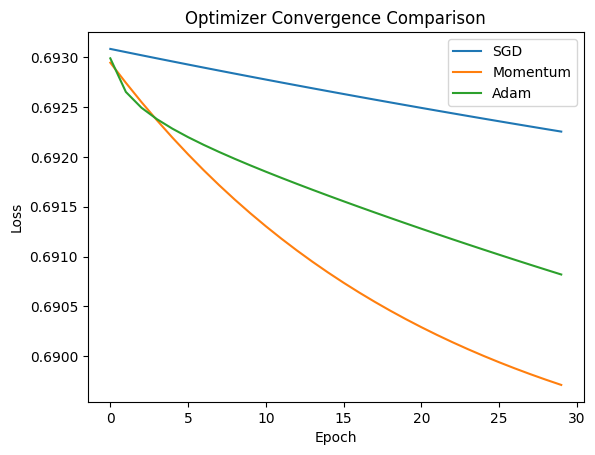

In [11]:
plt.plot(sgd_loss,label="SGD")
plt.plot(mom_loss,label="Momentum")
plt.plot(adam_loss,label="Adam")

plt.title("Optimizer Convergence Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

TEST ACCURACY

In [12]:
def test_accuracy(kernel,dense_w):

    correct=0

    for i in range(len(X_test)):

        pred,_ = forward(X_test[i],kernel,dense_w,0)

        if (pred>=0.5)==y_test[i]:
            correct+=1

    return correct/len(X_test)

print("\nTest Accuracy")
print("SGD:",test_accuracy(kernel_sgd,sgd_w))
print("Momentum:",test_accuracy(kernel_mom,mom_w))
print("Adam:",test_accuracy(kernel_adam,adam_w))


Test Accuracy
SGD: 0.43333333333333335
Momentum: 0.43333333333333335
Adam: 0.43333333333333335
